In [1]:
import h5py
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import math
import glob
import pickle

In [2]:
γ_list = [ "0.079477",  "0.25133", "0.79477", "2.5133", "7.9477", "25.133", "79.477", "251.33"]

In [3]:
Q = [316,  100,  31.6,   10,   3.16,    1,    0.316,    0.1]

In [4]:
def latest_file(pattern):
    files = sorted(glob.glob(pattern))
    if not files:
        raise FileNotFoundError(f"No file matching: {pattern}")
    print(files[-1])
    return files[-1]

In [5]:
def read_popdiff(file):
    popdiff = []
    for γ_i in γ_list:
        with h5py.File(file, 'r') as f:
            pd_arr = f[γ_i]["B2"]["PopDiff"][...]
            popdiff.append(pd_arr.tolist())
    return popdiff

In [6]:
kossak_tssos_pd   = read_popdiff(latest_file("E_KOSSAK_CONSTR_TSSOS_treshold_1e-15_FROB_QO_2026-Jun-14_at_16-44.h5"))

lindblad_tssos_pd = read_popdiff(latest_file("E_LINDBLAD4_CONSTR_TSSOS_treshold_1e-9_FROB_QO_2026-Jun-14_at_17-08.h5"))

#benchmark_kossak_pd  = read_popdiff(latest_file("E_BENCHMARK_TEST_KossakConstrFrob_Jump_NLOPT_LD_SLSQP*.h5"))

#benchmark_lindblad_pd = read_popdiff(latest_file("E_BENCHMARK_TEST_LindbladFrob_Jump_NLOPT_LD_SLSQP*.h5"))

#benchmark = benchmark_lindblad_pd[0:4] + benchmark_kossak_pd[4:8]

E_KOSSAK_CONSTR_TSSOS_treshold_1e-15_FROB_QO_2026-Jun-14_at_16-44.h5
E_LINDBLAD4_CONSTR_TSSOS_treshold_1e-9_FROB_QO_2026-Jun-14_at_17-08.h5


In [7]:
with open("NonMark.pkl", 'rb') as file:
        NonMark = pickle.load(file)

NonMark

array([1.54209546e-04, 1.29291467e-02, 5.91358315e-05, 7.10188411e-04,
       3.46324351e-02, 4.18774649e-02, 3.01774778e-03, 6.39944833e-04])

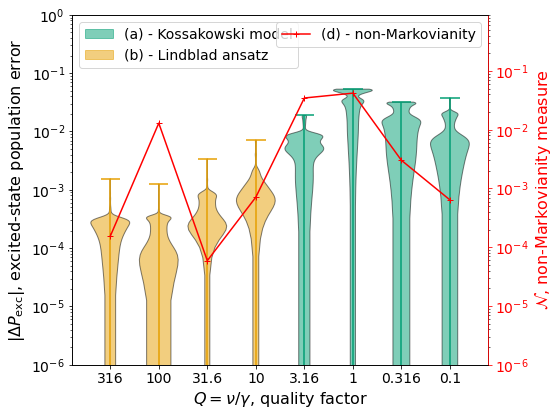

In [11]:
# Define a color-blind-friendly palette (Okabe-Ito)
color_blind_palette = ['#009E73', '#E69F00', '#CC79A7']  # Green, Orange, Purple

def set_violin_colors(violin, color, alpha=0.5, zorder=2):
    for body in violin['bodies']:
        body.set_facecolor(color)
        body.set_edgecolor('black')
        body.set_alpha(alpha)
        body.set_zorder(zorder)
    violin['cbars'].set_zorder(zorder)
    violin['cmins'].set_zorder(zorder)
    violin['cmaxes'].set_zorder(zorder)
    violin['cbars'].set_color(color)
    violin['cmins'].set_color(color)
    violin['cmaxes'].set_color(color)

plt.rcParams.update({'font.size': 14,
                     'axes.labelsize': 16,
                     'xtick.labelsize': 14,
                     'ytick.labelsize': 14,
                     'legend.fontsize': 14,
                     'axes.titlesize': 18})

labels = []

fig, ax1 = plt.subplots(figsize=(8, 6))

# Kossakowski model — high coupling (low Q), positions 5-8
violin1 = ax1.violinplot(kossak_tssos_pd[4:], positions=[5, 6, 7, 8], widths=0.8)
set_violin_colors(violin1, color_blind_palette[0], alpha=0.5, zorder=2)
labels.append((mpatches.Patch(color=color_blind_palette[0], alpha=0.5), "(a) - Kossakowski model"))

# Lindblad ansatz — low coupling (high Q), positions 1-4
violin2 = ax1.violinplot(lindblad_tssos_pd[:4], positions=[1, 2, 3, 4], widths=0.8)
set_violin_colors(violin2, color_blind_palette[1], alpha=0.5, zorder=2)
labels.append((mpatches.Patch(color=color_blind_palette[1], alpha=0.5), "(b) - Lindblad ansatz"))

# Benchmark — overlaid on both regions
#labels.append((mpatches.Patch(color=color_blind_palette[2], alpha=0.5), "(c) - Benchmark method"))

#violin31 = ax1.violinplot(benchmark[:4], positions=[1, 2, 3, 4], widths=0.6)
#set_violin_colors(violin31, color_blind_palette[2], alpha=0.5, zorder=1)

#violin32 = ax1.violinplot(benchmark[4:7], positions=[5, 6, 7], widths=0.6)
#set_violin_colors(violin32, color_blind_palette[2], alpha=0.5, zorder=2)

#violin33 = ax1.violinplot([benchmark[7]], positions=[8], widths=0.6)
#set_violin_colors(violin33, color_blind_palette[2], alpha=0.5, zorder=1)

# Non-Markovianity on second y-axis
ax2 = ax1.twinx()
ax2.plot(np.arange(1, 9), NonMark, marker="+", color="red", label="(d) - non-Markovianity")
ax2.set_yscale('log')
ax2.set_ylim(1e-6, .9)
ax2.set_ylabel('$\\mathcal{N}$, non-Markovianity measure', color='red')

ax1.set_yscale('log')
ax1.set_ylim(1e-6, 1.0)
ax1.set_xticks(range(1, len(γ_list) + 1), Q)
ax1.set_xlabel("$Q= \\nu / \\gamma$, quality factor")
ax1.set_ylabel("$|\\Delta P_{\\mathrm{exc}}|$, excited-state population error")

ax1.legend(*zip(*labels), loc=2)
ax2.tick_params(axis='y', colors='red')
ax2.spines['right'].set_color('red')
ax2.legend(loc=1)

plt.tight_layout()
plt.show()

fig.savefig("SB_SID_EXCITED_LINDBLAD&KOSSAK_CONSTR_TSSOS_vs_non_Markovianity_color-blind.PDF")